In [1]:
%%time
%matplotlib inline
import rioxarray
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import importlib 
import matplotlib.pyplot as plt

CPU times: total: 1.38 s
Wall time: 1.58 s


In [2]:
vv = rioxarray.open_rasterio('../input/STVV_202223.tif')
vh = rioxarray.open_rasterio('../input/STVH_202223.tif')
ndvi = rioxarray.open_rasterio('../input/STNDVI_202223.tif')


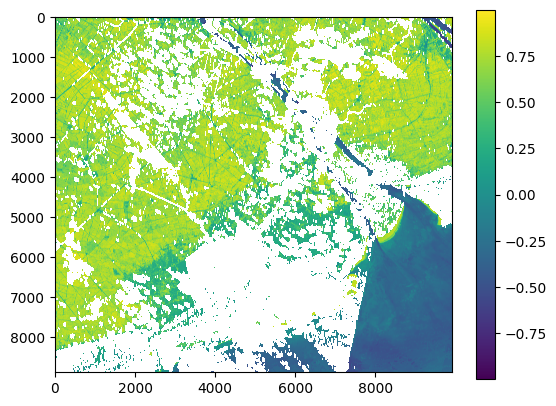

In [3]:
plt.imshow(ndvi[5], cmap='viridis')  # Display Band 10
plt.colorbar()  # Show the scale
plt.show()

In [4]:
ndvi

<xarray.DataArray (band: 13, y: 8874, x: 9902)> Size: 5GB
[1142314524 values with dtype=float32]
Coordinates:
  * band         (band) int64 104B 1 2 3 4 5 6 7 8 9 10 11 12 13
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      NDVI

In [3]:
import geopandas as gpd
train_path = "../input/STtrain1130v2.shp"  
# train_path = "train/updated_data/ThuanHoa_DKS_Kappa.shp"
ground_points = gpd.read_file(train_path)
ground_points.shape

(1130, 7)

In [4]:
ground_points

,No,X,Y,LU2022,Hientrang,HT_code,geometry
0,1,603860.819,1081162.862,Pomelo,CLN,3,POINT (603860.819 1081162.862)
1,2,601306.410,1082782.940,Pomelo,CLN,3,POINT (601306.41 1082782.94)
2,3,601084.510,1081351.870,Pomelo,CLN,3,POINT (601084.51 1081351.87)
3,4,602193.760,1079205.220,Pomelo,CLN,3,POINT (602193.76 1079205.22)
4,5,602459.000,1080946.000,Pomelo,CLN,3,POINT (602459 1080946)
...,...,...,...,...,...,...,...
1125,1126,NaN,NaN,None,Lua,1,POINT (615037.942 1073775.571)
1126,1127,NaN,NaN,None,Lua,1,POINT (607251.06 1074193.443)
1127,1128,NaN,NaN,None,Lua,1,POINT (610268.577 1076995.997)
1128,1129,NaN,NaN,None,Lua,1,POINT (602419.417 1058229.934)


In [4]:
def extract_data_with_HTcode(ground_points, average_ndvi, dsvh, dsvv):
    datasets = {}
    for idx, point in ground_points.iterrows():
        
        # Ensure each HT_code has its own dictionary
        if point.HT_code not in datasets:
            datasets[point.HT_code] = {'ndvi': [], 'vh': [], 'vv': []}
        # Get the data for this point
        ndvi_data = average_ndvi.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vh_data = dsvh.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vv_data = dsvv.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        
        # Append the data to the lists for this HT_code
        datasets[point.HT_code]['ndvi'].append(ndvi_data)
        datasets[point.HT_code]['vh'].append(vh_data)
        datasets[point.HT_code]['vv'].append(vv_data)
    
    return datasets

In [5]:
full_data = extract_data_with_HTcode(ground_points, ndvi, vh, vv)

In [61]:
ht_code = 7
lua2_ndvi = full_data[ht_code]['ndvi']
lua2_vh = full_data[ht_code]['vh']
lua2_ndvi

[array([       nan,        nan,        nan, 0.21564479, 0.17196263,
               nan, 0.21861434, 0.1914651 , 0.19430052,        nan,
               nan, 0.26065102,        nan], dtype=float32),
 array([       nan,        nan,        nan, 0.927878  , 0.93959355,
               nan, 0.8358911 , 0.8035717 , 0.88885707, 0.87401575,
               nan, 0.8364289 , 0.8605546 ], dtype=float32),
 array([0.88235295,        nan,        nan, 0.9117577 , 0.8369403 ,
        0.780072  , 0.83942777, 0.7812651 , 0.83309436, 0.7518942 ,
        0.7775091 , 0.5377745 , 0.8927429 ], dtype=float32),
 array([0.82463574,        nan,        nan, 0.80616707, 0.8519545 ,
               nan, 0.81269044, 0.7755049 , 0.7908058 , 0.84220266,
               nan, 0.8368267 , 0.6494712 ], dtype=float32),
 array([       nan, 0.78925335,        nan, 0.77911794, 0.81120944,
        0.7067934 , 0.78432155, 0.6620252 , 0.774137  , 0.78301084,
               nan, 0.77762383, 0.84056044], dtype=float32),
 array([       

In [7]:
len(lua2_vh)
# lua2_vh[0].shape[0]

168

In [65]:
import importlib
import fourierParam as params
# Reload module
importlib.reload(params)
months = np.arange(13)
scales = params.rung_scale 
bias = params.rung_bias

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
# bias =  0.6699999999998791
# scale_factor = 0.15279367314245765
# Tạo mảng lưu NDVI nội suy
ndvi_preds = []
for i, vh in enumerate(lua2_vh):
    
    fft_vh = fft(vh)
    intercep = fft_vh*scales
    res = np.real(ifft(intercep)) + bias
    ndvi_preds.append(res)

In [25]:
ndvi_preds

[array([0.69894874, 0.43531505, 0.58004851, 0.67551955, 0.53447836,
        0.37360531, 0.46177286, 0.56053289, 0.45341986, 0.41514051,
        0.63286433, 0.47439858, 0.3662041 ]),
 array([0.55979658, 0.44489178, 0.4219555 , 0.44142565, 0.59354652,
        0.56130342, 0.67476917, 0.37992731, 0.22498307, 0.48602788,
        0.66360732, 0.66422974, 0.78769559]),
 array([0.67142187, 0.8299418 , 0.65920978, 0.37396182, 0.29944458,
        0.4575225 , 0.33423467, 0.6078651 , 0.56405414, 0.61935203,
        0.38862545, 0.58977877, 0.50951357]),
 array([0.7535447 , 0.6310398 , 0.72583212, 0.36287463, 0.60348499,
        0.49749457, 0.69790405, 0.48449617, 0.36897472, 0.33072401,
        0.35547691, 0.535348  , 0.5421451 ]),
 array([0.51708588, 0.57746818, 0.40487432, 0.53866978, 0.25072487,
        0.44706312, 0.4417923 , 0.69908319, 0.62270884, 0.57586309,
        0.46997053, 0.57285061, 0.62313862]),
 array([0.44571112, 0.52350775, 0.68371415, 0.64048162, 0.56431775,
        0.50396271, 0.

In [26]:
# def normalize_to_minus1_1(array):
#     min_val = np.min(array)
#     max_val = np.max(array)
#     if max_val == min_val:  # Tránh chia cho 0
#         return np.zeros_like(array)
#     normalized = -1 + 2 * (array - min_val) / (max_val - min_val)
#     return normalized

# # Áp dụng chuẩn hóa cho từng mảng
# normalized_data = normalize_to_minus1_1(ndvi_preds)

# # In kết quả
# print(normalized_data)

In [27]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

def draw_ndvi(actual_values, predicted_values, name):
    for i, data in enumerate(actual_values):
        plt.plot(months, data, marker='o', linestyle='-', color='blue', markersize=4, linewidth=0.75, label='Actual Values (o)' if i == 0 else "")
    for i, data in enumerate(predicted_values):
        plt.plot(months, data, marker='x', linestyle='--', color='red', markersize=4, linewidth=0.75, label='predicted Values (o)' if i == 0 else "")
    plt.xlabel('Months')
    plt.ylabel('NDVI values')
    plt.title(f'Comparison: Actual vs Predicted Values in {name} code over 13 months')
    # Adding grid
    plt.grid(True)
    plt.legend(loc='best')
    # Adding legend to differentiate the lines
    plt.legend()
    # Adjusting the limits of the axes
    # plt.xlim(0, max(len(arr) for arr in actual_values))  # Adjust x-axis limits based on the longest array
    # plt.ylim(-1, 1)  # Example: Setting y-axis limits
    # Display the plot
    plt.show()

    


In [28]:
bias

1

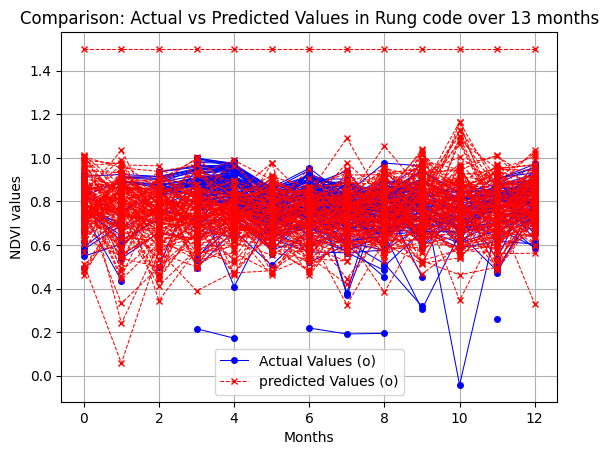

In [67]:
draw_ndvi(lua2_ndvi, ndvi_preds, "Rung")


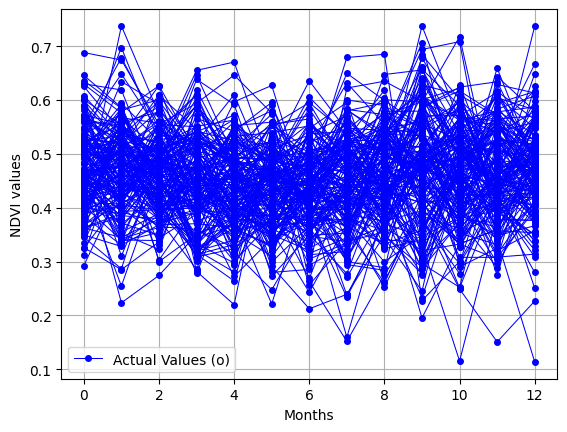

In [14]:

for i, data in enumerate(ndvi_preds):
    plt.plot(months, data, marker='o', linestyle='-', color='blue', markersize=4, linewidth=0.75, label='Actual Values (o)' if i == 0 else "")
plt.xlabel('Months')
plt.ylabel('NDVI values')
# Adding grid
plt.grid(True)
plt.legend(loc='best')

# Display the plot
plt.show()

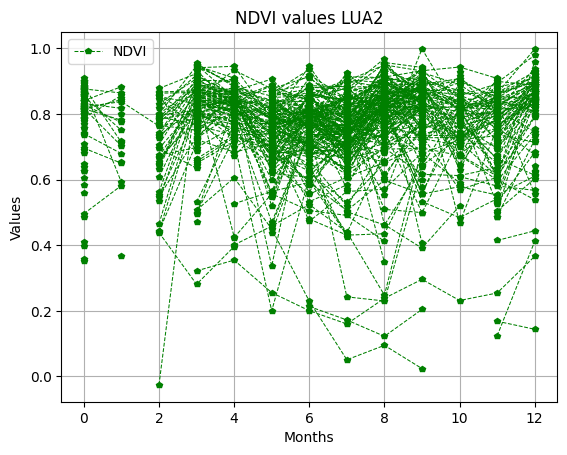

In [15]:
months = np.arange(13)
def draw_vh(vh_values):
    for i, vh in enumerate(vh_values[:]):
        plt.plot(months, vh, marker='p', ls="--", color="g", ms=4, lw=0.75, label='NDVI' if i == 0 else "")
    plt.grid(True)
    plt.legend(loc='best')
    plt.xlabel('Months')
    plt.ylabel('Values')
    plt.title(f'NDVI values LUA2')

draw_vh(lua2_ndvi)

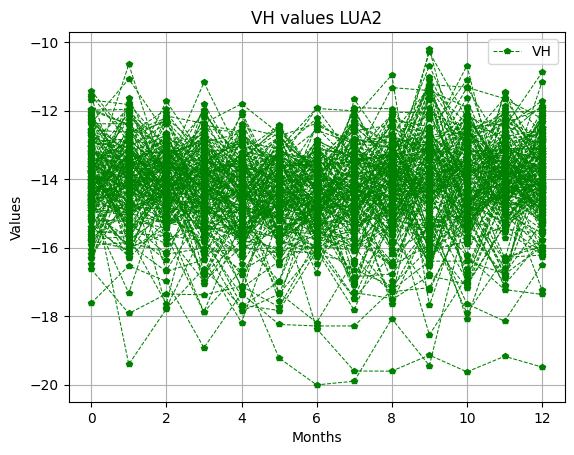

In [16]:
months = np.arange(13)
def draw_vh(vh_values):
    for i, vh in enumerate(vh_values[:]):
        plt.plot(months, vh, marker='p', ls="--", color="g", ms=4, lw=0.75, label='VH' if i == 0 else "")
    plt.grid(True)
    plt.legend(loc='best')
    plt.xlabel('Months')
    plt.ylabel('Values')
    plt.title(f'VH values LUA2')

draw_vh(lua2_vh)

In [ ]:
import numpy as np
import xarray as xr

ndvi_band = ndvi[5]
vh_band = vh[5]

# Tạo bản sao để không ghi đè dữ liệu gốc
ndvi_filled = ndvi_band.copy()

# Tìm vị trí bị NaN
mask_nan = np.isnan(ndvi_band)

# Gán giá trị mới vào chỗ NaN dựa trên VH
ndvi_filled.values[mask_nan.values] = estimate_ndvi_from_vh(vh_band.values[mask_nan.values])
